# Exploratory Data Analysis (EDA)

Before building features or training forecasting models, we must explore the dataset to understand its characteristics, uncover hourly/daily demand patterns, and detect anomalies.

In this notebook, we analyze the historical NYC Yellow Taxi pickup logs grouped by hour and location zone.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

# Load the preprocessed dataset
dataset_path = "../data/processed/training_dataset.parquet"
df = pd.read_parquet(dataset_path)

print(f"Dataset shape: {df.shape}")
print("Columns:", list(df.columns))
df.head()

Dataset shape: (71253, 8)
Columns: ['pickup_location_id', 'pickup_hour', 'pickup_count', 'hour', 'day_of_week', 'is_weekend', 'month', 'next_hour_pickup_count']


,pickup_location_id,pickup_hour,pickup_count,hour,day_of_week,is_weekend,month,next_hour_pickup_count
0,1,2022-10-24 17:00:00,1,17,0,False,10,1
1,1,2022-10-25 03:00:00,1,3,1,False,10,1
2,1,2023-01-01 05:00:00,1,5,6,True,1,1
3,1,2023-01-01 08:00:00,1,8,6,True,1,1
4,1,2023-01-01 11:00:00,1,11,6,True,1,3


## Summary Statistics
Let's look at the basic statistics of our demand data, especially the target column `next_hour_pickup_count`.

In [2]:
df["next_hour_pickup_count"].describe()

count    71253.000000
mean        42.985530
std         73.051339
min          1.000000
25%          1.000000
50%          7.000000
75%         55.000000
max        699.000000
Name: next_hour_pickup_count, dtype: float64

## Target Variable Distribution
Let's visualize the distribution of next-hour pickup demand across all zones. Notice the skewness of the target due to varying activity levels in different zones.

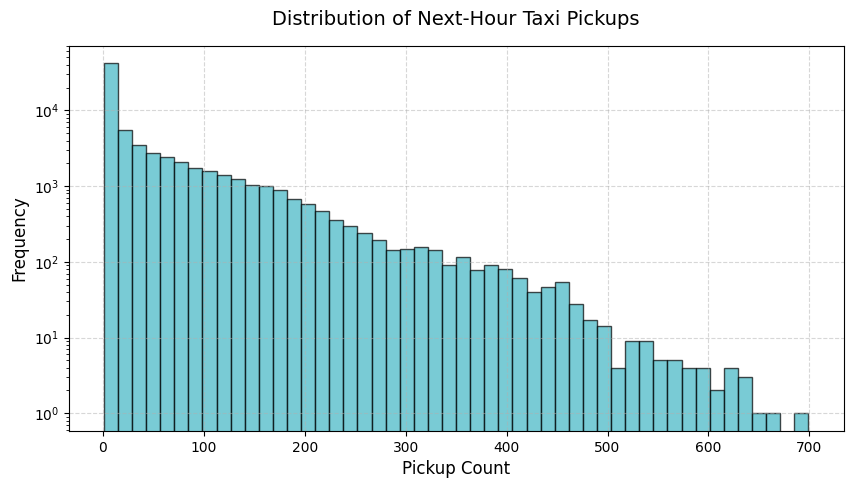

In [3]:
plt.figure(figsize=(10, 5))
plt.hist(
    df["next_hour_pickup_count"],
    bins=50,
    color="#41b6c4",
    edgecolor="black",
    alpha=0.7,
)
plt.title("Distribution of Next-Hour Taxi Pickups", fontsize=14, pad=15)
plt.xlabel("Pickup Count", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.yscale("log")  # Use log scale due to high skewness
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## Hourly and Daily Profiles
Let's inspect how demand varies by hour of the day and day of the week. Yellow taxi demand typically has strong diurnal patterns and rises during evening rush hours.

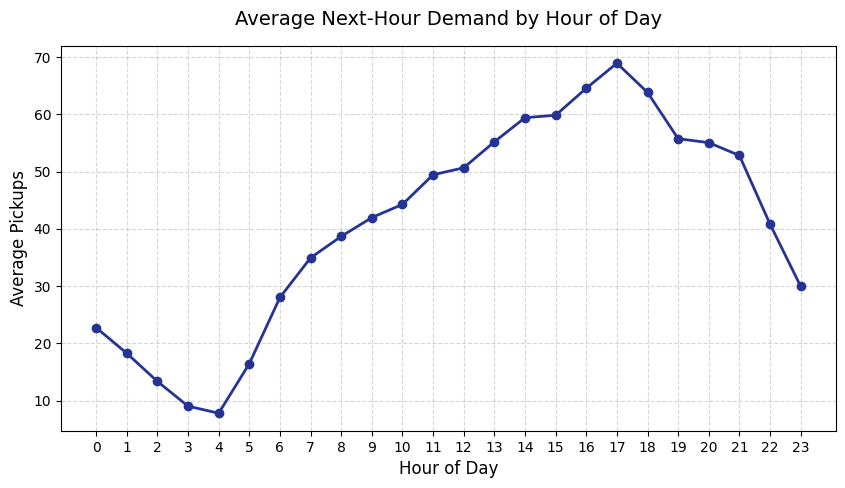

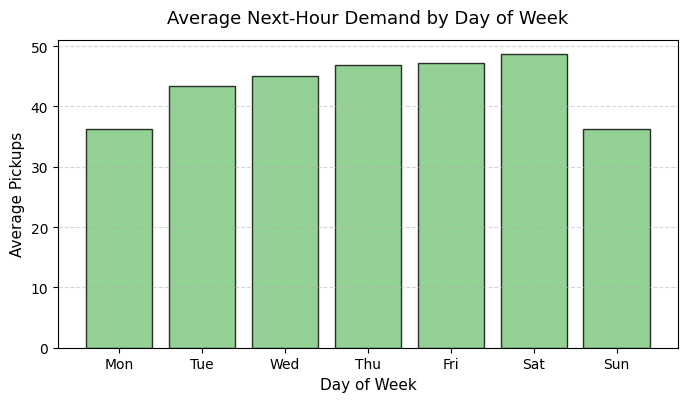

In [4]:
# Extract hour and day of week
df["pickup_hour"] = pd.to_datetime(df["pickup_hour"])
df["hour"] = df["pickup_hour"].dt.hour
df["day_of_week"] = df["pickup_hour"].dt.dayofweek

# Average pickups by hour
hourly_demand = df.groupby("hour")["next_hour_pickup_count"].mean()
plt.figure(figsize=(10, 5))
plt.plot(
    hourly_demand.index,
    hourly_demand.values,
    marker="o",
    color="#253494",
    linewidth=2,
)
plt.title("Average Next-Hour Demand by Hour of Day", fontsize=14, pad=15)
plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Average Pickups", fontsize=12)
plt.xticks(range(24))
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# Average pickups by day of week
weekly_demand = df.groupby("day_of_week")["next_hour_pickup_count"].mean()
days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
plt.figure(figsize=(8, 4))
plt.bar(
    days, weekly_demand.values, color="#78c679", edgecolor="black", alpha=0.8
)
plt.title("Average Next-Hour Demand by Day of Week", fontsize=13, pad=12)
plt.xlabel("Day of Week", fontsize=11)
plt.ylabel("Average Pickups", fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()